In [16]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler


from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISAdvanced, init_mf_params


In [17]:
# ---------------------------
# 1) Preparing the Swiss roll data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_swiss_roll_binary(n_samples=3000, noise=0.4):
    X3d, t = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=SEED)
    labels = (t > np.median(t)).astype(np.int64)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X3d).astype(np.float32)
    return X_scaled, labels


X, y = make_swiss_roll_binary()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)



In [29]:
# ---------------------------
# 5) Training loop
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert data to tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Initialize MF parameters
K = 2
init_method = "random_uniform"  # choose: "fcm", "random_uniform"
centers_init, spreads_init = init_mf_params(X_train, K, method=init_method, scale=1.0)

s_mode_choice = "alpha_beta"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

# Keep initial MF parameters for comparison
init_centers = model.mf_layer.c.detach().cpu().clone()
init_spreads = model.mf_layer.s.detach().cpu().clone()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Save best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Print progress every 150 epochs
    if epoch % 150 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_acc = (train_pred == y_train_tensor).float().mean().item()
            test_acc = (test_pred == y_test_tensor).float().mean().item()

        print(f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
              f"Train Acc {train_acc:.3f}  Test Acc {test_acc:.3f}")

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# Extract final MF parameters
final_centers = model.mf_layer.c.detach().cpu()
final_spreads = model.mf_layer.s.detach().cpu()

with torch.no_grad():
    # Predictions
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)
    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(final_test_logits).cpu().numpy().reshape(-1)

    # MF internals (return_parts=True for blend info)
    w, mu_g, mu_s, blend, mu_blend = model.mf_layer(X_test_tensor, return_parts=True)
    

# Function to summarize accuracy
def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | error {error:.3f} ({wrong} wrong points)")

print("\nFinal Results:")
print(f"Mode: {s_mode_choice}")
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)

# ---------------------------
# MF participation / contributions
# ---------------------------
# Contribution = blend * MF value (actual influence)
gauss_contrib = (blend * mu_g).mean(dim=0).cpu().numpy()  # per-rule, per-feature
sig_contrib = ((1 - blend) * mu_s).mean(dim=0).cpu().numpy()

# Raw participation (weights sum to 1)
gauss_weight = blend.mean(dim=0).cpu().numpy()
sig_weight = (1 - blend).mean(dim=0).cpu().numpy()

n_rules, n_features = gauss_contrib.shape

print("\nPer-rule, per-feature MF contributions and raw participation:")
for r in range(n_rules):
    for f in range(n_features):
        print(f"Rule {r}, Feature {f}: "
              f"Raw weight -> Gaussian={gauss_weight[r,f]:.4f}, Sigmoid={sig_weight[r,f]:.4f}")


Epoch 0001/1200  Loss 0.7066  Train Acc 0.370  Test Acc 0.373
Epoch 0150/1200  Loss 0.6592  Train Acc 0.633  Test Acc 0.625
Epoch 0300/1200  Loss 0.6096  Train Acc 0.665  Test Acc 0.648
Epoch 0450/1200  Loss 0.5260  Train Acc 0.847  Test Acc 0.858
Epoch 0600/1200  Loss 0.4340  Train Acc 0.946  Test Acc 0.947
Epoch 0750/1200  Loss 0.3593  Train Acc 0.976  Test Acc 0.980
Epoch 0900/1200  Loss 0.3096  Train Acc 0.987  Test Acc 0.987
Epoch 1050/1200  Loss 0.2758  Train Acc 0.990  Test Acc 0.990
Epoch 1200/1200  Loss 0.2513  Train Acc 0.991  Test Acc 0.993

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.991 (2378/2400 correct points) | error 0.009 (22 wrong points)
Test: accuracy rate 0.993 (596/600 correct points) | error 0.007 (4 wrong points)

Per-rule, per-feature MF contributions and raw participation:
Rule 0, Feature 0: Raw weight -> Gaussian=1.0000, Sigmoid=0.0000
Rule 0, Feature 1: Raw weight -> Gaussian=0.9604, Sigmoid=0.0396
Rule 0, Feature 2: Raw weight -> Gaussian=1.0000

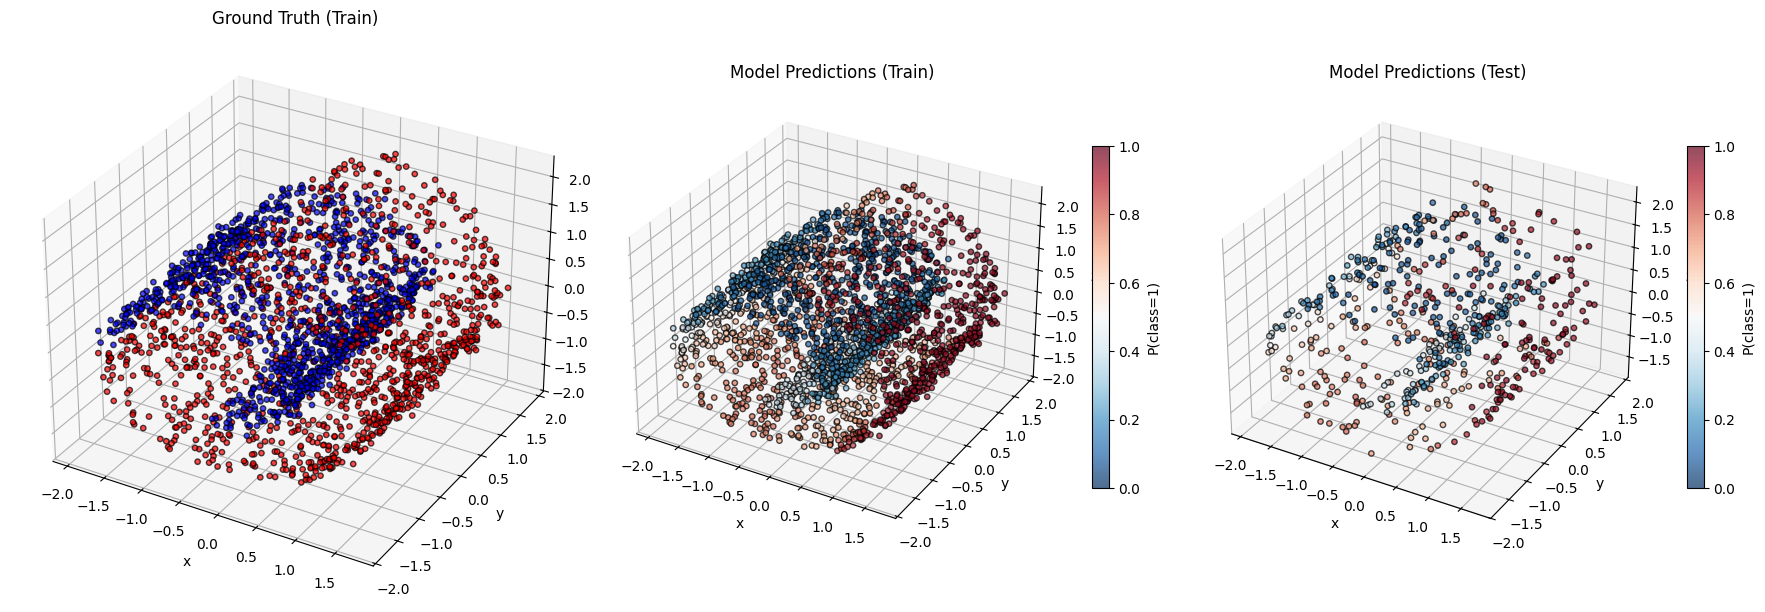

Train predictions - Min: 0.063, Max: 0.948
Test predictions - Min: 0.064, Max: 0.946


In [19]:
# ---------------------------
# 6) Visualization in 3D
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

with torch.no_grad():
    model.eval()
    # Compute test probabilities fresh
    test_logits = model(X_test_tensor)
    test_prob = torch.sigmoid(test_logits).cpu().numpy().reshape(-1)
    
    # Also get training probabilities for comparison
    train_logits = model(X_train_tensor)
    train_pred_prob = torch.sigmoid(train_logits).cpu().numpy().reshape(-1)

# Create 3D plots
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Ground truth labels (train)
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(
    X_train[:, 0], X_train[:, 1], X_train[:, 2],
    c=y_train, cmap="bwr", s=15, edgecolor="k", alpha=0.7
)
ax1.set_title("Ground Truth (Train)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

# Subplot 2: Model predictions (train)
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(
    X_train[:, 0], X_train[:, 1], X_train[:, 2],
    c=train_pred_prob, cmap="RdBu_r", s=15, edgecolor="k", alpha=0.7, vmin=0, vmax=1
)
ax2.set_title("Model Predictions (Train)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
fig.colorbar(sc2, ax=ax2, shrink=0.6, label="P(class=1)")

# Subplot 3: Model predictions (test)
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(
    X_test[:, 0], X_test[:, 1], X_test[:, 2],
    c=test_prob, cmap="RdBu_r", s=15, edgecolor="k", alpha=0.7, vmin=0, vmax=1
)
ax3.set_title("Model Predictions (Test)")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
fig.colorbar(sc3, ax=ax3, shrink=0.6, label="P(class=1)")

plt.tight_layout()
plt.show()

# Optional: Print some statistics
print(f"Train predictions - Min: {train_pred_prob.min():.3f}, Max: {train_pred_prob.max():.3f}")
print(f"Test predictions - Min: {test_prob.min():.3f}, Max: {test_prob.max():.3f}")

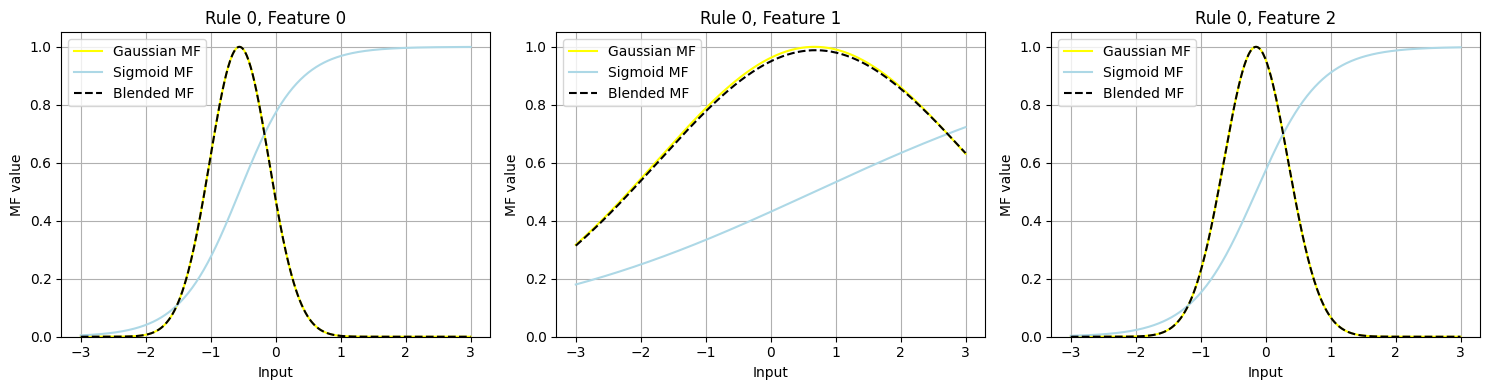

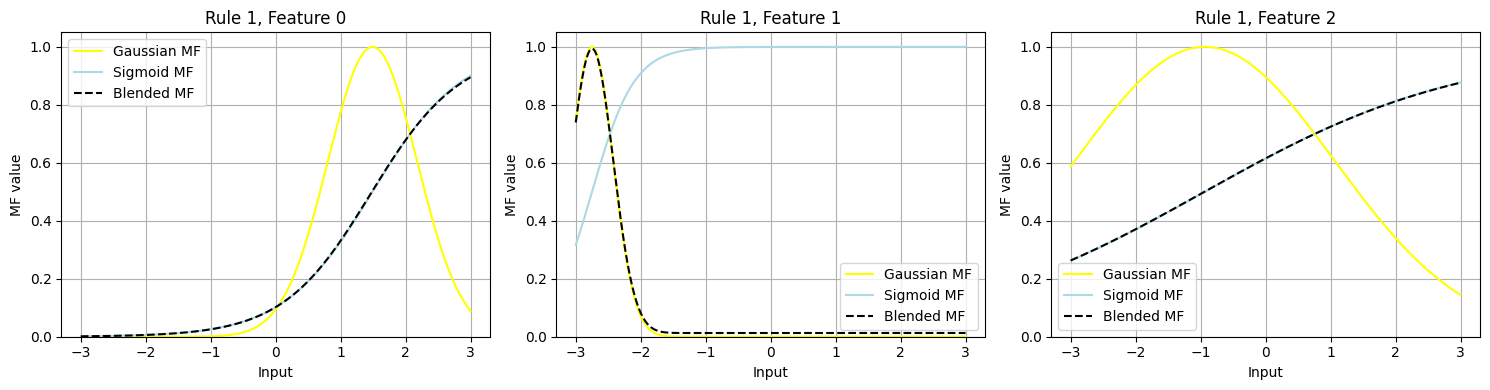

In [20]:
def plot_mfs_rule(model, rule, x_range=(-3, 3), n=400):
    """Plot Gaussian, Sigmoid, and blended MFs for all features of one rule in a single row."""
    
    n_features = model.n_inputs
    x = np.linspace(*x_range, n, dtype=np.float32)
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(next(model.parameters()).device)
    
    with torch.no_grad():
        w, mu_gauss, mu_sig, blend, mu_blend = model.mf_layer(x_tensor, return_parts=True)

    fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 4))
    if n_features == 1:
        axes = [axes]  # ensure axes is iterable
    
    for f, ax in enumerate(axes):
        mu_g = mu_gauss[:, rule, f].cpu().numpy()
        mu_s = mu_sig[:, rule, f].cpu().numpy()
        mu_b = mu_blend[:, rule, f].cpu().numpy()

        ax.plot(x, mu_g, label='Gaussian MF', color='yellow')
        ax.plot(x, mu_s, label='Sigmoid MF', color='lightblue')
        ax.plot(x, mu_b, '--', label='Blended MF', color='black')
        ax.set_title(f"Rule {rule}, Feature {f}")
        ax.set_xlabel("Input")
        ax.set_ylabel("MF value")
        ax.set_ylim(0, 1.05)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Example usage: plot all features of each rule
for r in range(model.K):
    plot_mfs_rule(model, r)
